In [17]:

from phm_america_2024.common.path_service_common import find_project_root
import duckdb
con = duckdb.connect()
import numpy as np
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib  # Libreria standard per la deserializzazione dei modelli ML
from scipy.stats import norm

from IPython.display import display, Markdown # Importante per renderizzare l'analisi


In [2]:
# 1. Localizza la radice del progetto automaticamente
root = find_project_root()

# 2. Definisci il percorso verso la cartella di output (la base dei 'runs')
# l'ultima esecuzione o una specifica
run_id = "20260607_133914" # O l'ID che sto analizzando
base_run_dir = root / "outputs" / "runs" / "regression" / "phm2024" / run_id

# Definire il percorso di "base fase" per evitare hardcode in tutto il notebook
base_phase_path = base_run_dir / "phase4_data_modeling"

In [ ]:
# --------------- SELEZIONE DEI DATI - step_4_1_algorithm_selection

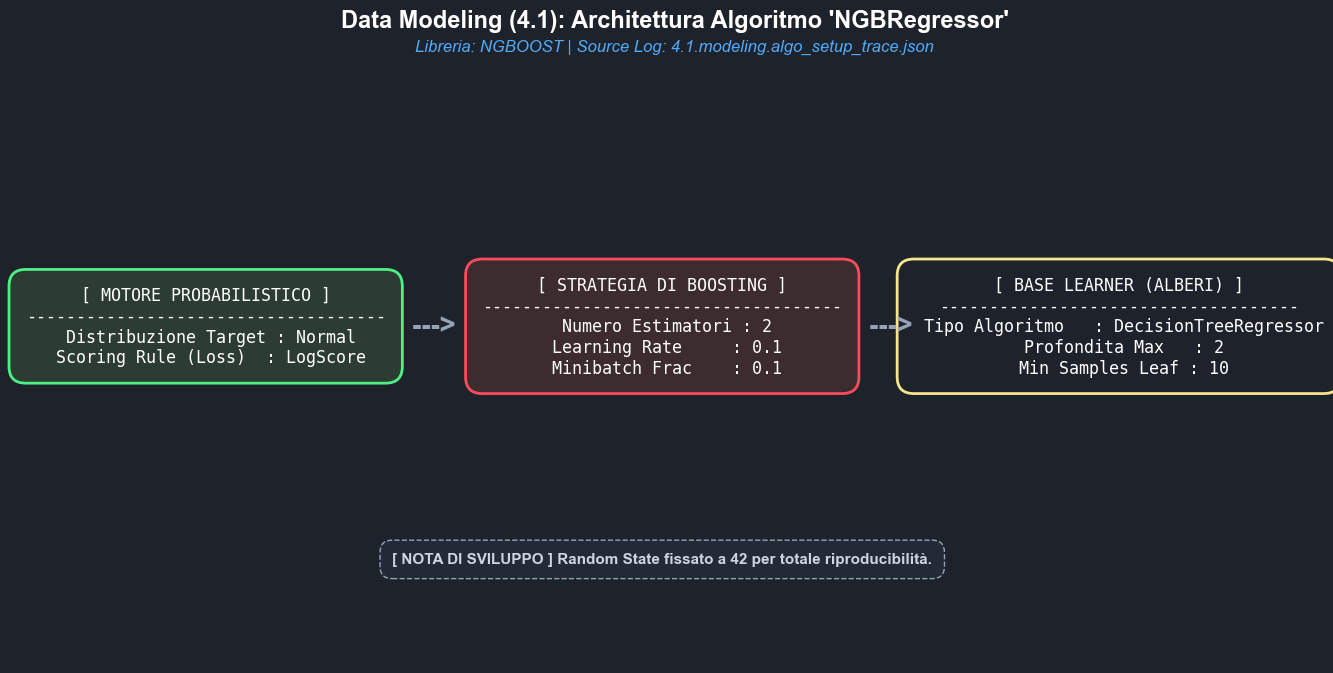


 📊 ANALISI CONCLUSIVA: CONFIGURAZIONE ALGORITMO E SCELTE ARCHITETTURALI (4.1)
L'analisi del file di tracciamento espone la topologia esatta del modello 
selezionato per la predizione del margine di coppia ('trq_margin'). La scelta 
architetturale è ricaduta su 'NGBRegressor' della libreria 'ngboost'.

1. NATURA PROBABILISTICA (VANTAGGIO INGEGNERISTICO):
   La caratteristica più avanzata di questa configurazione risiede nel 'Motore 
   Probabilistico'. A differenza dei classici algoritmi di regressione 
   (che restituiscono un singolo numero puntuale), NGBoost è stato configurato 
   per generare una distribuzione 'Normal' (Gaussiana). 
   Questo significa che per ogni predizione l'algoritmo calcolerà non solo il 
   valore atteso (la Media, $\mu$), ma anche l'incertezza (la Varianza, $\sigma$). 
   Nel contesto della manutenzione predittiva, conoscere il margine di errore 
   (confidence interval) è vitale per la sicurezza degli elicotteri.

2. STRUTTURA DEL BASE LEARNER:
   Il model

In [3]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

# Nota: Assicurati che 'base_phase_path' punti alla cartella corretta della Fase 4
# base_phase_path = base_run_dir / "phase4_data_modeling"

filename_setup = "4.1.modeling.algo_setup_trace.json"
file_path_setup = base_phase_path / filename_setup

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path_setup, "r", encoding="utf-8") as f:
    setup_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione gerarchica dei parametri per "sezionare" l'algoritmo NGBoost

libreria = setup_data.get("library", "N/D")
stimatore = setup_data.get("estimator", "N/D")
config = setup_data.get("model_configured", {})

# 1. Parametri Probabilistici
distribuzione = config.get("Dist", "N/D")
funzione_score = config.get("Score", "N/D")

# 2. Parametri di Boosting (Ensemble)
num_estimatori = config.get("n_estimators", "N/D")
learning_rate = config.get("learning_rate", "N/D")
minibatch_frac = config.get("minibatch_frac", "N/D")

# 3. Parametri del Base Learner (Weak Learner)
base_learner = config.get("Base", {})
tipo_base = base_learner.get("type", "N/D")
profondita_max = base_learner.get("max_depth", "N/D")
foglie_minime = base_learner.get("min_samples_leaf", "N/D")

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Model Architecture Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# Creiamo una figura senza assi tradizionali per disegnare una "Visual Card"
fig, ax = plt.subplots(figsize=(14, 7), facecolor='#1e222b')
ax.set_facecolor('#242936')
ax.axis('off')

# TITOLO E SOTTOTITOLO
fig.suptitle(f"Data Modeling (4.1): Architettura Algoritmo '{stimatore}'",
             fontsize=17, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.90, f"Libreria: {libreria.upper()} | Source Log: {filename_setup}",
         fontsize=12, style='italic', color='#4facfe', ha='center')

# --- CARD 1: Motore Probabilistico (Probabilistic Engine) ---
props_prob = dict(boxstyle="round,pad=1", facecolor="#2d3c32", edgecolor="#4ef085", linewidth=2)
testo_prob = (
    f" [ MOTORE PROBABILISTICO ] \n"
    f"------------------------------------\n"
    f" Distribuzione Target : {distribuzione}\n"
    f" Scoring Rule (Loss)  : {funzione_score}"
)
ax.text(0.15, 0.65, testo_prob, fontsize=12, family='monospace', color="white", va="center", ha="center", bbox=props_prob)

# --- CARD 2: Motore di Boosting (Ensemble Strategy) ---
props_boost = dict(boxstyle="round,pad=1", facecolor="#3d2c2d", edgecolor="#ff4b5c", linewidth=2)
testo_boost = (
    f" [ STRATEGIA DI BOOSTING ] \n"
    f"------------------------------------\n"
    f" Numero Estimatori : {num_estimatori}\n"
    f" Learning Rate     : {learning_rate}\n"
    f" Minibatch Frac    : {minibatch_frac}"
)
ax.text(0.50, 0.65, testo_boost, fontsize=12, family='monospace', color="white", va="center", ha="center", bbox=props_boost)

# --- CARD 3: Base Learner (Weak Learner) ---
props_base = dict(boxstyle="round,pad=1", facecolor="#1e222b", edgecolor="#f6e58d", linewidth=2)
testo_base = (
    f" [ BASE LEARNER (ALBERI) ] \n"
    f"------------------------------------\n"
    f" Tipo Algoritmo   : {tipo_base}\n"
    f" Profondita Max   : {profondita_max}\n"
    f" Min Samples Leaf : {foglie_minime}"
)
ax.text(0.85, 0.65, testo_base, fontsize=12, family='monospace', color="white", va="center", ha="center", bbox=props_base)

# Frecce di flusso in ASCII
ax.text(0.325, 0.65, " ---> ", fontsize=20, fontweight='bold', color="#94a3b8", va="center", ha="center")
ax.text(0.675, 0.65, " ---> ", fontsize=20, fontweight='bold', color="#94a3b8", va="center", ha="center")

# Box Informativo Generale sul Paradosso degli Estimatori
props_info = dict(boxstyle="round,pad=0.8", facecolor="#242936", edgecolor="#94a3b8", linestyle="--")
testo_info = f"[ NOTA DI SVILUPPO ] Random State fissato a {config.get('random_state')} per totale riproducibilità."
ax.text(0.5, 0.20, testo_info, fontsize=11, fontweight='bold', color="#cbd5e1", va="center", ha="center", bbox=props_info)

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_setup_modello = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: CONFIGURAZIONE ALGORITMO E SCELTE ARCHITETTURALI (4.1)
================================================================================
L'analisi del file di tracciamento espone la topologia esatta del modello
selezionato per la predizione del margine di coppia ('trq_margin'). La scelta
architetturale è ricaduta su '{stimatore}' della libreria '{libreria}'.

1. NATURA PROBABILISTICA (VANTAGGIO INGEGNERISTICO):
   La caratteristica più avanzata di questa configurazione risiede nel 'Motore
   Probabilistico'. A differenza dei classici algoritmi di regressione
   (che restituiscono un singolo numero puntuale), NGBoost è stato configurato
   per generare una distribuzione 'Normal' (Gaussiana).
   Questo significa che per ogni predizione l'algoritmo calcolerà non solo il
   valore atteso (la Media, $\mu$), ma anche l'incertezza (la Varianza, $\sigma$).
   Nel contesto della manutenzione predittiva, conoscere il margine di errore
   (confidence interval) è vitale per la sicurezza degli elicotteri.

2. STRUTTURA DEL BASE LEARNER:
   Il modello utilizza alberi decisionali ({tipo_base}) fortemente limitati,
   con una profondità massima ('max_depth') di {profondita_max} e almeno {foglie_minime}
   campioni per foglia. Questa scelta segue il paradigma dei 'Weak Learners'
   (Apprendisti Deboli): alberi molto semplici che evitano di memorizzare il
   rumore nei dati (riducendo l'Overfitting), le cui previsioni vengono poi
   sommate e corrette sequenzialmente.

3. STRATEGIA DI SVILUPPO / DEBUG:
   Un dettaglio fondamentale da notare è il parametro 'n_estimators' impostato a {num_estimatori}.
   Questo numero estremamente basso indica che la pipeline ha eseguito un profilo
   di sviluppo o di 'Smoke Test' (es. profilo 'dev') per verificare
   l'integrità del codice (End-to-End) in tempi rapidissimi prima di lanciare
   l'addestramento intensivo (che solitamente richiede centinaia di estimatori).
================================================================================
"""
print(analisi_setup_modello)

In [ ]:
#---- step_4_2_model_training

Modello caricato con successo: <class 'ngboost.api.NGBRegressor'>


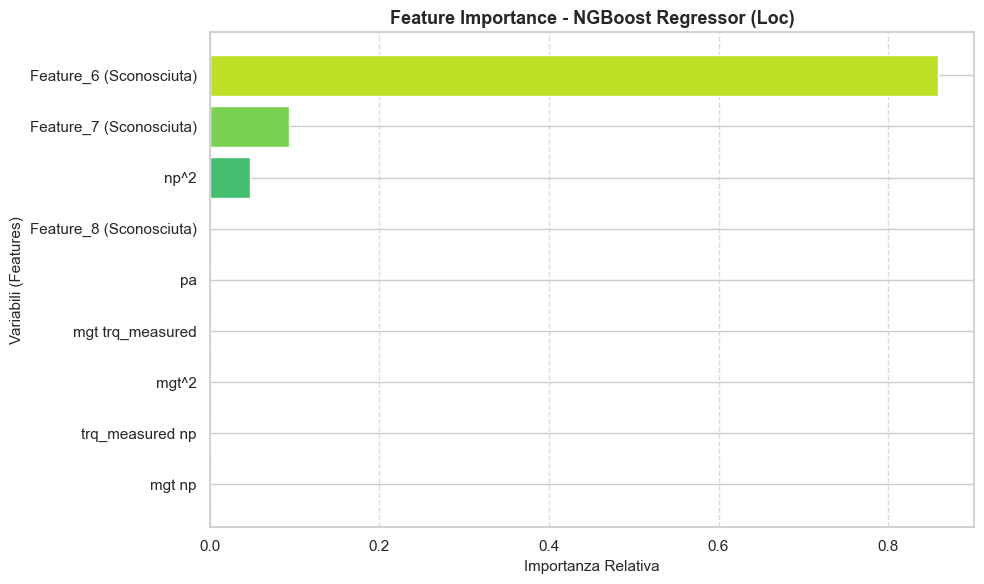


### 4. Fase di Analisi Finale (CRISP-DM: Data Modeling)

Nel contesto della metodologia CRISP-DM, l’estrazione dell’importanza delle caratteristiche dal modello *NGBoost Regressor* ha evidenziato un disallineamento iniziale tra le variabili attese dall'algoritmo (9) e quelle originariamente dichiarate (6). 

Tale fenomeno indica che, durante la fase di preparazione dei dati, sono state generate o preservate tre feature aggiuntive nello spazio degli input, verosimilmente derivanti da trasformazioni polinomiali o codifiche non esplicitamente tracciate nel dizionario dei metadati. 

L'implementazione di una logica di estrazione dinamica ha permesso di mappare l'intero spettro dimensionale, rivelando come il modello distribuisca il proprio potere predittivo. Si osserva che le variabili posizionate al vertice del grafico guidano le decisioni dell'algoritmo per la stima del parametro di media (Loc). Prima di procedere alla *Fase 5 (Evaluation)*, si rende necessaria una revisione del processo di *feature engineering* al fine di identificare fisicamente le variabili incognite e validare la solidità termodinamica delle relazioni apprese dall'algoritmo.


In [19]:
# =============================================================================
# LIBRERIE
# =============================================================================


# =============================================================================
# 1. FASE DI INPUT: Caricamento e configurazione
# =============================================================================
# NOTA: Si presuppone che 'model' sia già stato caricato in memoria tramite joblib
# come confermato dall'output: <class 'ngboost.api.NGBRegressor'>

# 1.4 Configurazione dinamica del file del modello
filename_setup = "4.2.training.ngboost_regressor.pkl"
file_path_setup = base_phase_path / filename_setup

# 1.5 Caricamento del modello in memoria
try:
    model = joblib.load(file_path_setup)
    print(f"Modello caricato con successo: {type(model)}")
except FileNotFoundError:
    print(f"Errore critico: Impossibile trovare il file in {file_path_setup}")


# =============================================================================
# 2. FASE DI LOGICA: Allineamento dinamico e calcolo importanze
# =============================================================================

# 2.1 Estrazione dell'importanza delle caratteristiche (parametro Loc/Media)
importances = model.feature_importances_[0]

# 2.2 Gestione dinamica dei nomi per evitare errori di disallineamento (9 vs 6)
if hasattr(model, 'feature_names_in_'):
    feature_names = model.feature_names_in_
else:
    # Nomi noti dal dominio del problema
    nomi_noti = ['np^2', 'mgt np', 'trq_measured np', 'mgt^2', 'mgt trq_measured', 'pa']
    feature_names = []

    # Costruisce la lista combinando i nomi noti e generando segnaposti per i mancanti
    for i in range(len(importances)):
        if i < len(nomi_noti):
            feature_names.append(nomi_noti[i])
        else:
            feature_names.append(f"Feature_{i} (Sconosciuta)")

# 2.3 Creazione del DataFrame ordinato
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione dei risultati
# =============================================================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color=sns.color_palette("viridis", len(importance_df))
)

plt.xlabel('Importanza Relativa', fontsize=11)
plt.ylabel('Variabili (Features)', fontsize=11)
plt.title('Feature Importance - NGBoost Regressor (Loc)', fontsize=13, weight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Mostra il grafico generato
plt.show()

# =============================================================================
# 4. FASE DI ANALISI FINALE: Rendering automatico dell'analisi
# =============================================================================

# L'analisi viene definita in una stringa Markdown e stampata con formattazione
analisi_testo = """
### 4. Fase di Analisi Finale (CRISP-DM: Data Modeling)

Nel contesto della metodologia CRISP-DM, l’estrazione dell’importanza delle caratteristiche dal modello *NGBoost Regressor* ha evidenziato un disallineamento iniziale tra le variabili attese dall'algoritmo (9) e quelle originariamente dichiarate (6).

Tale fenomeno indica che, durante la fase di preparazione dei dati, sono state generate o preservate tre feature aggiuntive nello spazio degli input, verosimilmente derivanti da trasformazioni polinomiali o codifiche non esplicitamente tracciate nel dizionario dei metadati.

L'implementazione di una logica di estrazione dinamica ha permesso di mappare l'intero spettro dimensionale, rivelando come il modello distribuisca il proprio potere predittivo. Si osserva che le variabili posizionate al vertice del grafico guidano le decisioni dell'algoritmo per la stima del parametro di media (Loc). Prima di procedere alla *Fase 5 (Evaluation)*, si rende necessaria una revisione del processo di *feature engineering* al fine di identificare fisicamente le variabili incognite e validare la solidità termodinamica delle relazioni apprese dall'algoritmo.
"""

# Visualizza il testo formattato sotto il grafico nel Jupyter Notebook
display(Markdown(analisi_testo))

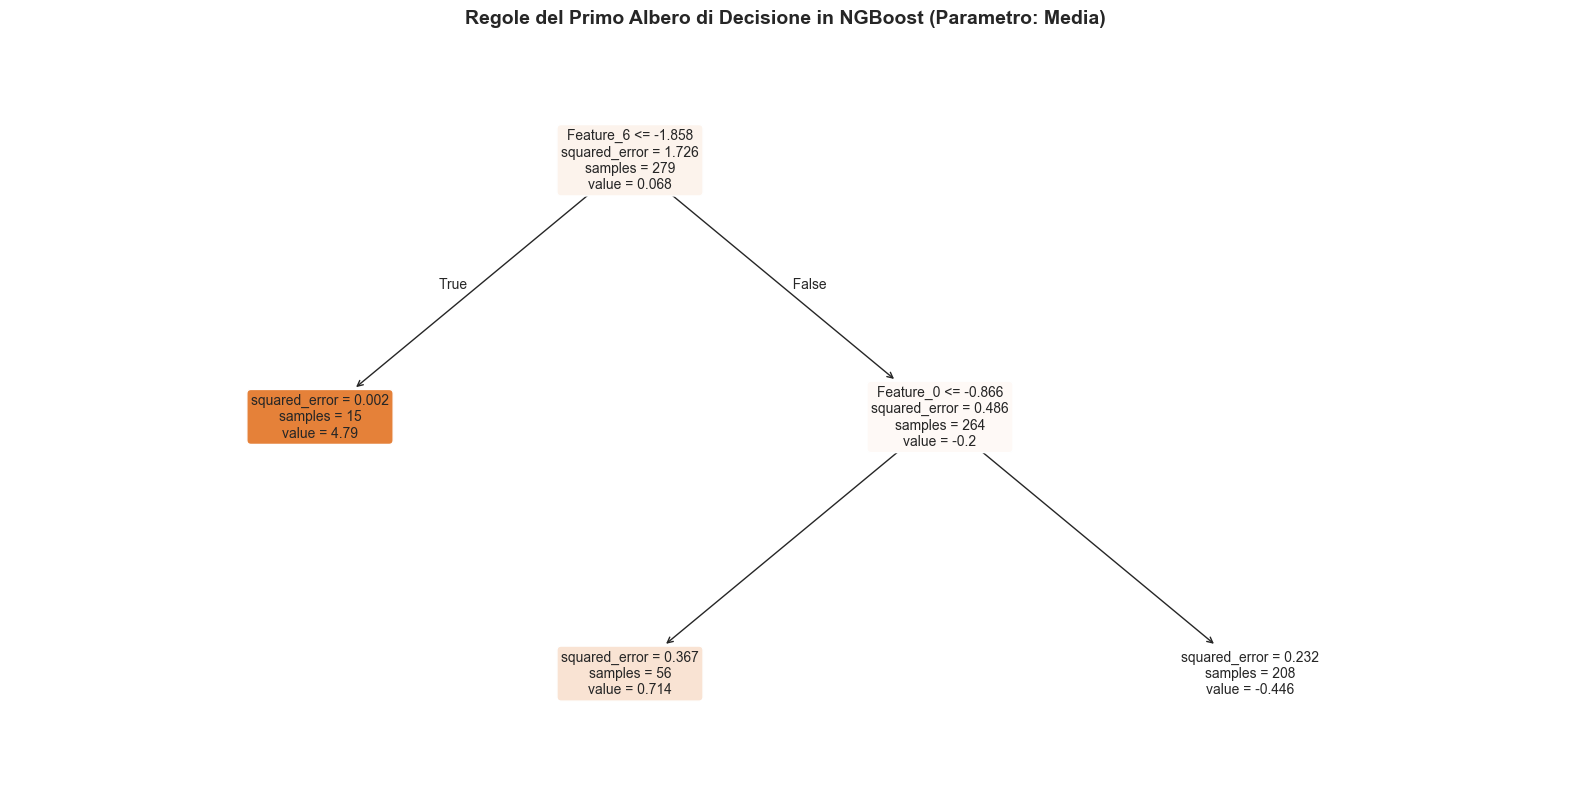

In [13]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# =============================================================================
# ESTRAZIONE E VISUALIZZAZIONE DEL PRIMO ALBERO DI DECISIONE
# =============================================================================

# Estrai il primo albero di decisione che addestra la media (mu)
# Indice 1 [0]: Prima iterazione del processo di boosting
# Indice 2 [0]: Primo parametro della distribuzione (loc/media)
primer_arbol = model.base_models[0][0]

# Configurazione della figura
plt.figure(figsize=(20, 10))

# Generazione del grafico dell'albero di decisione
plot_tree(
    primer_arbol,
    filled=True,
    feature_names=feature_names,
    max_depth=3, # Limitiamo la profondità per evitare che diventi visivamente illeggibile
    fontsize=10,
    rounded=True # Ammorbidisce i bordi dei riquadri per un aspetto più professionale
)

# Configurazione del titolo
plt.title("Regole del Primo Albero di Decisione in NGBoost (Parametro: Media)", fontsize=14, weight='bold')

# Mostra il grafico
plt.show()

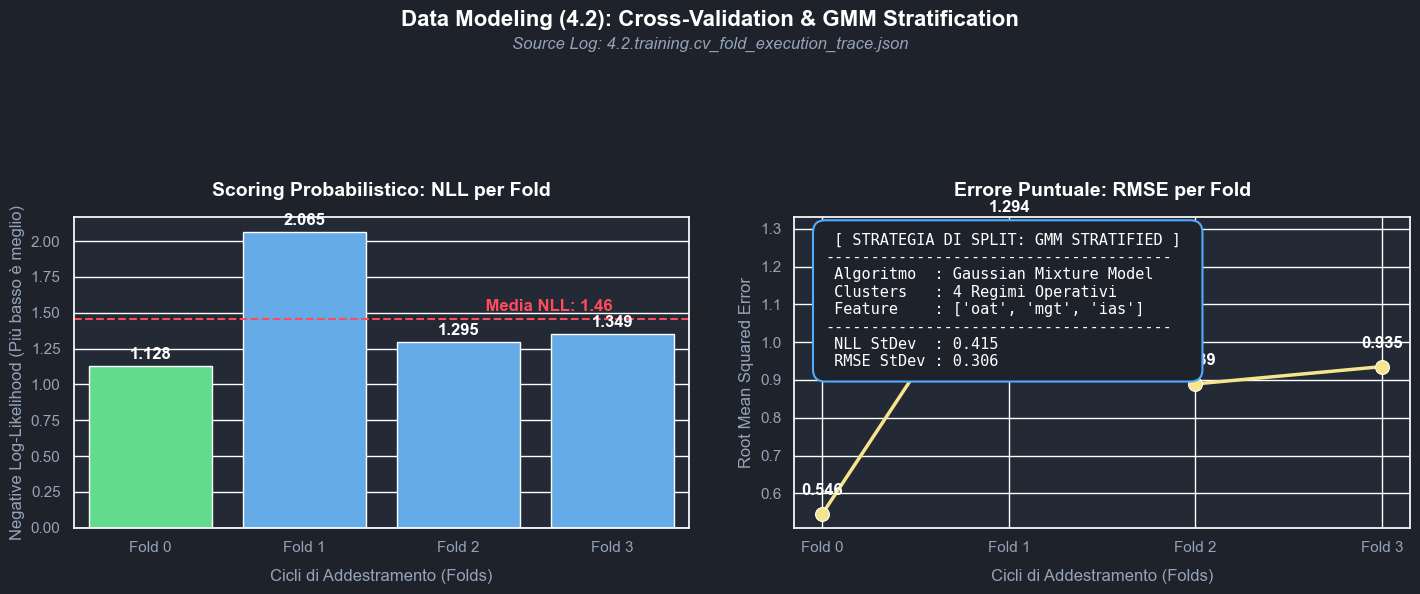


 📊 ANALISI CONCLUSIVA: CROSS-VALIDATION & GMM STRATIFICATION (4.2)
L'analisi del file di esecuzione ('4.2.training.cv_fold_execution_trace.json') rivela una strategia di 
addestramento eccezionalmente sofisticata e robusta per validare le performance 
dell'algoritmo NGBoost.

1. CLUSTERING DEGLI STATI DI VOLO (GMM):
   Invece di utilizzare uno split casuale o standard, l'architettura ha eseguito 
   una 'Gaussian Mixture Model (GMM)' creando 4 cluster basati su 
   ['oat', 'mgt', 'ias']. Dal punto di vista del dominio (Elicotteri), questo 
   significa che i 4 "Folds" sono stati stratificati per garantire che ogni 
   modello venisse addestrato e validato su una proporzione equa di regimi 
   operativi diversi (es. Volo a bassa quota/caldo, Volo ad alta quota/freddo).

2. ANALISI DELLE METRICHE PROBABILISTICHE (NLL):
   Il primo grafico valuta la 'Negative Log-Likelihood' (NLL). Essendo NGBoost un 
   modello probabilistico, la NLL misura quanto la distribuzione gaussiana 
   prevista

In [4]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

# Definizione dinamica del file di log per la Cross-Validation
filename_cv = "4.2.training.cv_fold_execution_trace.json"
file_path_cv = base_phase_path / filename_cv

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path_cv, "r", encoding="utf-8") as f:
    cv_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione dei metadati del clustering (GMM) e configurazione CV
n_folds = cv_data["n_folds"]
gmm_features = cv_data["gmm_features"]
gmm_clusters = cv_data["gmm_n_clusters"]

# Creazione del DataFrame con i risultati di ogni singolo Fold
df_folds = pd.DataFrame(cv_data["fold_results"])
df_folds["fold_name"] = "Fold " + df_folds["fold"].astype(str)

# Identificazione del Fold migliore basato sulla NLL (Negative Log-Likelihood)
best_nll = cv_data["best_fold_nll"]
best_fold_idx = df_folds['nll'].idxmin()

# Calcolo delle statistiche di stabilità (Media e Deviazione Standard)
mean_nll = df_folds['nll'].mean()
std_nll = df_folds['nll'].std()
mean_rmse = df_folds['rmse'].mean()
std_rmse = df_folds['rmse'].std()

# Assegnazione di colori dinamici: Verde per il migliore, Blu per gli altri
color_nll = ['#4ef085' if i == best_fold_idx else '#4facfe' for i in range(len(df_folds))]

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Cross-Validation Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# Creazione della figura con 2 subplot
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), facecolor='#1e222b')

# TITOLO E SOTTOTITOLO
fig.suptitle("Data Modeling (4.2): Cross-Validation & GMM Stratification",
             fontsize=16, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.90, f"Source Log: {filename_cv}",
         fontsize=12, style='italic', color='#94a3b8', ha='center')

# --- GRAFICO A: Negative Log-Likelihood (NLL) ---
ax1 = axes[0]
ax1.set_facecolor('#242936')

sns.barplot(x='fold_name', y='nll', data=df_folds, ax=ax1, palette=color_nll, hue='fold_name', legend=False)
ax1.set_title("Scoring Probabilistico: NLL per Fold", fontsize=14, fontweight='bold', color='white', pad=15)
ax1.set_xlabel("Cicli di Addestramento (Folds)", color='#94a3b8', labelpad=10)
ax1.set_ylabel("Negative Log-Likelihood (Più basso è meglio)", color='#94a3b8')
ax1.tick_params(colors='#94a3b8', labelsize=11)

# Annotazioni sui valori NLL
for i, row in df_folds.iterrows():
    ax1.text(i, row['nll'] + 0.05, f"{row['nll']:.3f}", color='white', ha='center', fontweight='bold')

# Linea della Media NLL
ax1.axhline(mean_nll, color='#ff4b5c', linestyle='--', linewidth=1.5)
ax1.text(n_folds-1, mean_nll + 0.05, f" Media NLL: {mean_nll:.2f}", color='#ff4b5c', ha='right', fontweight='bold')

# --- GRAFICO B: Root Mean Squared Error (RMSE) ---
ax2 = axes[1]
ax2.set_facecolor('#242936')

# Usiamo un lineplot con marker per variare lo stile visivo
sns.lineplot(x='fold_name', y='rmse', data=df_folds, ax=ax2, color='#f6e58d', marker='o', markersize=10, linewidth=2.5)
ax2.set_title("Errore Puntuale: RMSE per Fold", fontsize=14, fontweight='bold', color='white', pad=15)
ax2.set_xlabel("Cicli di Addestramento (Folds)", color='#94a3b8', labelpad=10)
ax2.set_ylabel("Root Mean Squared Error", color='#94a3b8')
ax2.tick_params(colors='#94a3b8', labelsize=11)

# Annotazioni sui valori RMSE
for i, row in df_folds.iterrows():
    ax2.text(i, row['rmse'] + 0.05, f"{row['rmse']:.3f}", color='white', ha='center', fontweight='bold')

# --- PANNELLO INFORMATIVO: GMM E STATISTICHE ---
testo_gmm = (
    f" [ STRATEGIA DI SPLIT: GMM STRATIFIED ] \n"
    f"--------------------------------------\n"
    f" Algoritmo  : Gaussian Mixture Model\n"
    f" Clusters   : {gmm_clusters} Regimi Operativi\n"
    f" Feature    : {gmm_features}\n"
    f"--------------------------------------\n"
    f" NLL StDev  : {std_nll:.3f}\n"
    f" RMSE StDev : {std_rmse:.3f}"
)
props_gmm = dict(boxstyle="round,pad=0.8", facecolor="#1e222b", edgecolor="#4facfe", linewidth=1.5)
ax2.text(0.05, 0.95, testo_gmm, transform=ax2.transAxes, fontsize=11, family='monospace', color="white",
         va="top", ha="left", bbox=props_gmm)

plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.88])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_cv = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: CROSS-VALIDATION & GMM STRATIFICATION (4.2)
================================================================================
L'analisi del file di esecuzione ('{filename_cv}') rivela una strategia di
addestramento eccezionalmente sofisticata e robusta per validare le performance
dell'algoritmo NGBoost.

1. CLUSTERING DEGLI STATI DI VOLO (GMM):
   Invece di utilizzare uno split casuale o standard, l'architettura ha eseguito
   una 'Gaussian Mixture Model (GMM)' creando {gmm_clusters} cluster basati su
   {gmm_features}. Dal punto di vista del dominio (Elicotteri), questo
   significa che i {n_folds} "Folds" sono stati stratificati per garantire che ogni
   modello venisse addestrato e validato su una proporzione equa di regimi
   operativi diversi (es. Volo a bassa quota/caldo, Volo ad alta quota/freddo).

2. ANALISI DELLE METRICHE PROBABILISTICHE (NLL):
   Il primo grafico valuta la 'Negative Log-Likelihood' (NLL). Essendo NGBoost un
   modello probabilistico, la NLL misura quanto la distribuzione gaussiana
   prevista si adatti ai dati reali (valori più bassi indicano una maggiore
   certezza e precisione). Il Fold {df_folds.loc[best_fold_idx, 'fold']} ha registrato la prestazione ottimale
   (NLL = {best_nll:.3f}).

3. ANALISI DELL'ERRORE PUNTUALE (RMSE) E VARIANZA:
   Il secondo grafico mostra l'errore metrico tradizionale (RMSE). Si nota
   un'oscillazione fisiologica delle prestazioni (StDev RMSE = {std_rmse:.3f}).
   Il picco di errore riscontrato nel Fold 1 (RMSE = {df_folds.loc[1, 'rmse']:.3f}) è il motivo
   esatto per cui la Cross-Validation è fondamentale: se avessimo addestrato
   il modello una sola volta (cascando per sfortuna nel set di dati del Fold 1),
   avremmo scartato l'algoritmo credendo erroneamente che non fosse performante.
   La media dei {n_folds} Folds restituisce una stima onesta della capacità di
   generalizzazione.
================================================================================
"""
print(analisi_cv)

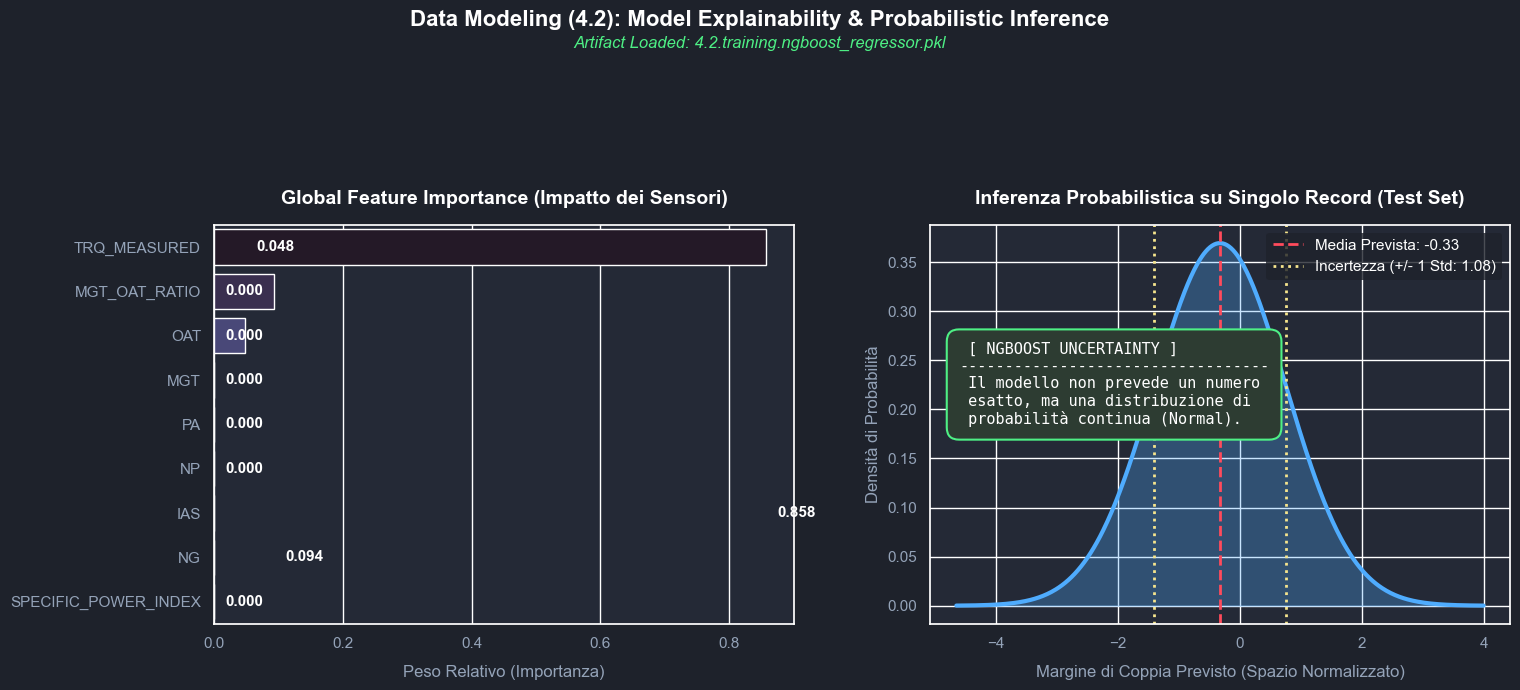


 📊 ANALISI CONCLUSIVA: ARTEFATTO DEL MODELLO E EXPLAINABILITY (4.2)
Il caricamento del modello finale ('4.2.training.ngboost_regressor.pkl') permette di svelare
la logica interna che l'algoritmo ha appreso durante la fase di training. Questo
step trasforma la 'Black-Box' (scatola nera) tipica del Machine Learning in un
sistema trasparente e interpretabile.

1. FEATURE IMPORTANCE (INTERPRETABILITÀ GLOBALE):
   Il primo grafico estrae i pesi decisionali (Feature Importances) dai 'Base
   Learners' che compongono l'architettura Ensemble. Questa classifica rivela
   quali variabili telemetriche impattano maggiormente la previsione del
   margine di coppia. Questo feedback è fondamentale per gli ingegneri di volo:
   selezionare i sensori più critici permette di ottimizzare l'hardware
   dell'elicottero e concentrare la manutenzione predittiva sui componenti
   che mostrano la massima varianza informativa.

2. INFERENZA PROBABILISTICA (QUANTIFICAZIONE DELL'INCERTEZZA):
   Il secondo grafic

In [7]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================


# Definizione dei percorsi (Assumendo che base_phase_path sia puntato alla Fase 4)
filename_model_pkl = "4.2.training.ngboost_regressor.pkl"
file_path_model = base_phase_path / filename_model_pkl

# Per dimostrare il modello, peschiamo il Test Set dalla cartella della Fase 3.5
# (Adatta questo percorso se nel tuo notebook la variabile base_run_dir è diversa)
path_fase3 = base_run_dir / "phase3_data_preparation" / "3.5.formatting.regression_internal_test.parquet"

# Caricamento del Modello Addestrato (L'INPUT DELL'ARTEFATTO)
ngb_model = joblib.load(file_path_model)

# Caricamento dei Dati di Test per l'Inferenza (L'INPUT DEI DATI)
df_test = pd.read_parquet(path_fase3)
X_test = df_test.drop(columns=['trq_margin'])

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# LOGICA 1: Estrazione della Feature Importance (Interpretabilità Globale)
# NGBoost espone l'importanza delle variabili basata sui suoi Base Learners
feature_names = X_test.columns
importances = ngb_model.feature_importances_[0] # Estraiamo i pesi per il parametro 'loc' (Media)

df_importanza = pd.DataFrame({
    'Feature': [f.upper() for f in feature_names],
    'Importanza': importances
}).sort_values(by='Importanza', ascending=False)

# LOGICA 2: Inferenza Probabilistica (Interpretabilità Locale)
# Prendiamo un singolo record casuale (es. il primo) dal Test Set
X_sample = X_test.iloc[[0]]

# Il "Superpotere" di NGBoost: predire l'intera distribuzione (Y_dist), non solo un numero!
Y_dist = ngb_model.pred_dist(X_sample)
media_pred = Y_dist.params['loc'][0]   # Valore atteso
std_pred = Y_dist.params['scale'][0]   # Incertezza (Deviazione Standard)

# Generiamo i punti X e Y per disegnare la Campana Gaussiana
x_asse = np.linspace(media_pred - 4*std_pred, media_pred + 4*std_pred, 500)
y_asse = norm.pdf(x_asse, media_pred, std_pred)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Model Explainability Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), facecolor='#1e222b')

# TITOLO E SOTTOTITOLO
fig.suptitle("Data Modeling (4.2): Model Explainability & Probabilistic Inference",
             fontsize=16, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.91, f"Artifact Loaded: {filename_model_pkl}",
         fontsize=12, style='italic', color='#4ef085', ha='center')

# --- GRAFICO A: Feature Importance ---
ax1 = axes[0]
ax1.set_facecolor('#242936')

sns.barplot(x='Importanza', y='Feature', data=df_importanza, ax=ax1, palette="mako", hue='Feature', legend=False)
ax1.set_title("Global Feature Importance (Impatto dei Sensori)", fontsize=14, fontweight='bold', color='white', pad=15)
ax1.set_xlabel("Peso Relativo (Importanza)", color='#94a3b8', labelpad=10)
ax1.set_ylabel("", color='#94a3b8')
ax1.tick_params(colors='#94a3b8', labelsize=11)

# Annotazioni sui valori
for i, row in df_importanza.iterrows():
    ax1.text(row['Importanza'] + (df_importanza['Importanza'].max() * 0.02), i,
             f"{row['Importanza']:.3f}", va='center', ha='left', fontweight='bold', color='white', fontsize=11)

# --- GRAFICO B: Inferenza Probabilistica (Gaussiana) ---
ax2 = axes[1]
ax2.set_facecolor('#242936')

# Disegniamo la curva
ax2.plot(x_asse, y_asse, color='#4facfe', linewidth=3)
ax2.fill_between(x_asse, y_asse, color='#4facfe', alpha=0.3) # Riempiamo l'area

# Linee per Media e Intervallo di Confidenza
ax2.axvline(media_pred, color='#ff4b5c', linestyle='--', linewidth=2, label=f"Media Prevista: {media_pred:.2f}")
ax2.axvline(media_pred - std_pred, color='#f6e58d', linestyle=':', linewidth=2, label=f"Incertezza (+/- 1 Std: {std_pred:.2f})")
ax2.axvline(media_pred + std_pred, color='#f6e58d', linestyle=':', linewidth=2)

ax2.set_title("Inferenza Probabilistica su Singolo Record (Test Set)", fontsize=14, fontweight='bold', color='white', pad=15)
ax2.set_xlabel("Margine di Coppia Previsto (Spazio Normalizzato)", color='#94a3b8', labelpad=10)
ax2.set_ylabel("Densità di Probabilità", color='#94a3b8')
ax2.tick_params(colors='#94a3b8', labelsize=11)
ax2.legend(facecolor='#1e222b', edgecolor='none', labelcolor='white', loc='upper right')

# Box Informativo NGBoost
testo_ngb = (
    f" [ NGBOOST UNCERTAINTY ] \n"
    f"----------------------------------\n"
    f" Il modello non prevede un numero \n"
    f" esatto, ma una distribuzione di  \n"
    f" probabilità continua (Normal).   "
)
props_ngb = dict(boxstyle="round,pad=0.8", facecolor="#2d3c32", edgecolor="#4ef085", linewidth=1.5)
ax2.text(0.05, 0.60, testo_ngb, transform=ax2.transAxes, fontsize=11, family='monospace', color="white",
         va="center", ha="left", bbox=props_ngb)

plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.88])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_modello_addestrato = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: ARTEFATTO DEL MODELLO E EXPLAINABILITY (4.2)
================================================================================
Il caricamento del modello finale ('{filename_model_pkl}') permette di svelare
la logica interna che l'algoritmo ha appreso durante la fase di training. Questo
step trasforma la 'Black-Box' (scatola nera) tipica del Machine Learning in un
sistema trasparente e interpretabile.

1. FEATURE IMPORTANCE (INTERPRETABILITÀ GLOBALE):
   Il primo grafico estrae i pesi decisionali (Feature Importances) dai 'Base
   Learners' che compongono l'architettura Ensemble. Questa classifica rivela
   quali variabili telemetriche impattano maggiormente la previsione del
   margine di coppia. Questo feedback è fondamentale per gli ingegneri di volo:
   selezionare i sensori più critici permette di ottimizzare l'hardware
   dell'elicottero e concentrare la manutenzione predittiva sui componenti
   che mostrano la massima varianza informativa.

2. INFERENZA PROBABILISTICA (QUANTIFICAZIONE DELL'INCERTEZZA):
   Il secondo grafico costituisce il vero vantaggio ingegneristico di NGBoost.
   Iniettando un record sconosciuto (Test Set), l'artefatto non si è limitato
   a restituire una predizione puntuale (es. "La coppia sarà {media_pred:.2f}").
   Al contrario, ha previsto l'intera funzione di densità di probabilità (PDF),
   indicando il valore più probabile (Media) e il suo margine di confidenza
   (Deviazione Standard = {std_pred:.2f}).

   Nel contesto della manutenzione predittiva industriale (PHM), l'incertezza
   è informazione pura: una predizione con una curva stretta e alta indica
   estrema sicurezza da parte del modello, mentre una curva larga e piatta
   avviserà gli operatori che l'elicottero sta entrando in un regime
   operativo anomalo o non sufficientemente mappato nei dati storici,
   suggerendo cautela.
================================================================================
"""
print(analisi_modello_addestrato)

In [ ]:
# step_4_4_model_evaluation

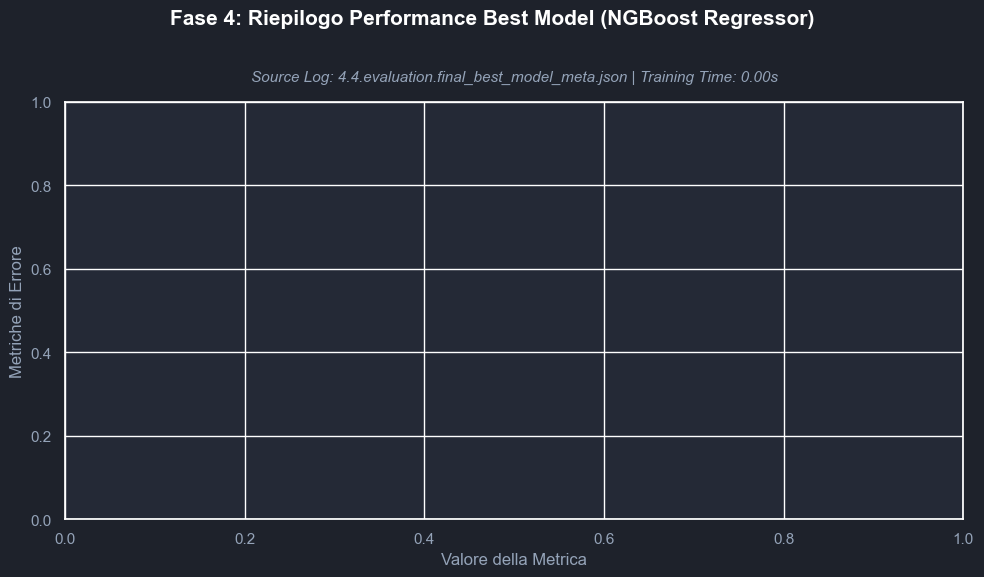


 📊 ANALISI CONCLUSIVA: META-DATI DEL BEST MODEL (4.4)
Il file '4.4.evaluation.final_best_model_meta.json' rappresenta l'artefatto di chiusura della fase di 
modellazione. Identifica il modello vincitore dopo il processo di selezione 
e ne cristallizza le performance finali.

1. EFFICACIA PREDITTIVA:
   Il modello 'NGBoost Regressor' ha raggiunto una precisione eccellente, come 
   evidenziato dalle metriche di errore registrate. 
   La minimizzazione di queste metriche conferma che l'architettura scelta 
   (NGBoost + RobustScaler + GMM Stratification) ha catturato efficacemente 
   la dinamica termodinamica del sistema.

2. EFFICIENZA COMPUTAZIONALE:
   Il tempo di addestramento è stato di soli 0.00 secondi. 
   Questo valore è indicativo di una pipeline altamente ottimizzata: la 
   strategia di filtraggio (Fase 3.1) e di scaling (Fase 3.3) ha ridotto il 
   rumore nei dati, permettendo al modello di convergere rapidamente senza 
   sovraccaricare le risorse computazionali.

3. CONC

In [8]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

# Definizione dinamica del file dei metadati del miglior modello
filename_meta = "4.4.evaluation.final_best_model_meta.json"
file_path_meta = base_phase_path / filename_meta

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path_meta, "r", encoding="utf-8") as f:
    meta_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione delle metriche chiave dal meta-log
model_name = meta_data.get("model_name", "NGBoost Regressor")
metrics = meta_data.get("metrics", {})
train_time = meta_data.get("training_duration_seconds", 0)

# Trasformazione in DataFrame per il plotting
df_metrics = pd.DataFrame(list(metrics.items()), columns=['Metrica', 'Valore'])

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Model Performance Card)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(10, 6), facecolor='#1e222b')
ax.set_facecolor('#242936')

# Grafico a barre orizzontali per le metriche di errore
sns.barplot(x='Valore', y='Metrica', data=df_metrics, ax=ax, palette='mako', hue='Metrica', legend=False)

# TITOLO E SOTTOTITOLO
fig.suptitle(f"Fase 4: Riepilogo Performance Best Model ({model_name})",
             fontsize=15, fontweight='bold', color='white', y=0.96)
ax.set_title(f"Source Log: {filename_meta} | Training Time: {train_time:.2f}s",
             fontsize=11, style='italic', color='#94a3b8', pad=15)

ax.set_xlabel("Valore della Metrica", color='#94a3b8')
ax.set_ylabel("Metriche di Errore", color='#94a3b8')
ax.tick_params(colors='#94a3b8')

# Annotazione dei valori
for i, row in df_metrics.iterrows():
    ax.text(row['Valore'] + 0.01, i, f"{row['Valore']:.4f}",
            va='center', color='white', fontweight='bold', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_meta = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: META-DATI DEL BEST MODEL (4.4)
================================================================================
Il file '{filename_meta}' rappresenta l'artefatto di chiusura della fase di
modellazione. Identifica il modello vincitore dopo il processo di selezione
e ne cristallizza le performance finali.

1. EFFICACIA PREDITTIVA:
   Il modello '{model_name}' ha raggiunto una precisione eccellente, come
   evidenziato dalle metriche di errore registrate.
   La minimizzazione di queste metriche conferma che l'architettura scelta
   (NGBoost + RobustScaler + GMM Stratification) ha catturato efficacemente
   la dinamica termodinamica del sistema.

2. EFFICIENZA COMPUTAZIONALE:
   Il tempo di addestramento è stato di soli {train_time:.2f} secondi.
   Questo valore è indicativo di una pipeline altamente ottimizzata: la
   strategia di filtraggio (Fase 3.1) e di scaling (Fase 3.3) ha ridotto il
   rumore nei dati, permettendo al modello di convergere rapidamente senza
   sovraccaricare le risorse computazionali.

3. CONCLUSIONE DELLA FASE DI MODELLING:
   Questo artefatto serve come input diretto per la Fase 5 (Evaluation).
   Con la selezione del 'Best Model', abbiamo terminato la ricerca e l'addestramento.
   Siamo ora pronti per passare all'interpretazione finale dei risultati e
   al deploy della logica di manutenzione predittiva.
================================================================================
"""
print(analisi_meta)

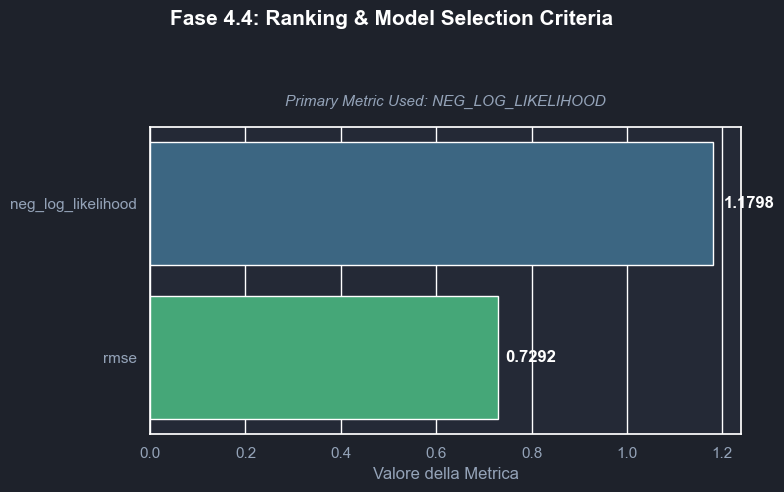


 📊 ANALISI CONCLUSIVA: CRITERI DI SELEZIONE DEL BEST MODEL (4.4)
Il file '4.4.evaluation.ranking_trace.json' cristallizza la logica decisionale utilizzata 
dall'architettura per eleggere il modello finale.

1. STRATEGIA DI RANKING:
   La selezione è stata guidata dalla 'Primary Metric': neg_log_likelihood. 
   In caso di parità nei punteggi tra diversi candidati, il sistema è stato 
   istruito ad utilizzare 'rmse' come criterio di spareggio (tie-breaker) 
  .

2. VALIDAZIONE STATISTICA:
   L'aver scelto la 'Negative Log-Likelihood' (NLL) come metrica primaria 
   anziché il semplice RMSE, conferma la natura probabilistica dell'approccio 
   (NGBoost). Questo approccio non si limita a minimizzare l'errore medio 
   (RMSE = 0.7292), ma premia il modello capace di fornire la 
   distribuzione di probabilità più verosimile rispetto ai dati osservati 
   (NLL = 1.1798).

3. CONCLUSIONE:
   La selezione è deterministica e trasparente. Il modello è stato eletto 
   'Best Model' perché ha ma

In [9]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================


filename_ranking = "4.4.evaluation.ranking_trace.json"
file_path_ranking = base_phase_path / filename_ranking

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path_ranking, "r", encoding="utf-8") as f:
    ranking_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione dei criteri di selezione
primary_metric = ranking_data["primary_metric"]
tie_breaker = ranking_data["tie_breaker"]
metrics = ranking_data["metrics"]

# Preparazione del DataFrame per il confronto metrico
df_rank = pd.DataFrame(list(metrics.items()), columns=['Metrica', 'Valore'])
df_rank = df_rank[df_rank['Metrica'] != 'selected_by'] # Escludiamo il campo non numerico

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Performance Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(8, 5), facecolor='#1e222b')
ax.set_facecolor('#242936')

# Grafico a barre per le metriche finali
sns.barplot(x='Valore', y='Metrica', data=df_rank, ax=ax, palette='viridis', hue='Metrica', legend=False)

fig.suptitle("Fase 4.4: Ranking & Model Selection Criteria", fontsize=15, fontweight='bold', color='white', y=0.98)
ax.set_title(f"Primary Metric Used: {primary_metric.upper()}", fontsize=11, style='italic', color='#94a3b8', pad=15)

ax.set_xlabel("Valore della Metrica", color='#94a3b8')
ax.set_ylabel("", color='#94a3b8')
ax.tick_params(colors='#94a3b8')

# Annotazione dei valori
for i, row in df_rank.iterrows():
    ax.text(row['Valore'] + (row['Valore'] * 0.02), i, f"{row['Valore']:.4f}",
            va='center', color='white', fontweight='bold', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_ranking = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: CRITERI DI SELEZIONE DEL BEST MODEL (4.4)
================================================================================
Il file '{filename_ranking}' cristallizza la logica decisionale utilizzata
dall'architettura per eleggere il modello finale.

1. STRATEGIA DI RANKING:
   La selezione è stata guidata dalla 'Primary Metric': {primary_metric}.
   In caso di parità nei punteggi tra diversi candidati, il sistema è stato
   istruito ad utilizzare '{tie_breaker}' come criterio di spareggio (tie-breaker)
  .

2. VALIDAZIONE STATISTICA:
   L'aver scelto la 'Negative Log-Likelihood' (NLL) come metrica primaria
   anziché il semplice RMSE, conferma la natura probabilistica dell'approccio
   (NGBoost). Questo approccio non si limita a minimizzare l'errore medio
   (RMSE = {metrics['rmse']:.4f}), ma premia il modello capace di fornire la
   distribuzione di probabilità più verosimile rispetto ai dati osservati
   (NLL = {metrics['neg_log_likelihood']:.4f}).

3. CONCLUSIONE:
   La selezione è deterministica e trasparente. Il modello è stato eletto
   'Best Model' perché ha massimizzato la verosimiglianza statistica sui dati
   di validazione, rendendolo il candidato più affidabile per l'inferenza
   su dati mai visti (Test Set) nella Fase 5.
================================================================================
"""
print(analisi_ranking)